<center>

# ⠀
---

# **Analyse Numérique**

## **TP1 : Interpolation polynômiale**


---
<br>



####**MANSOURI Koussay**

<br>


</center>

---

## I - Erreur d’interpolation de Lagrange

### I.A - Un peu de calcul

> Soit $f$ la fonction définie telle que :
>
>$$f : \left[0, \frac{\pi}{2}\right] \longrightarrow \mathbb{R}$$
>
>$$x \longmapsto \cos{(2x)}$$
>
> Déterminer (à la main) le polynôme d’interpolation de Lagrange $P$ vérifiant :
>
>$$P(0)=f(0), \quad P\left(\frac{\pi}{6}\right)=f\left(\frac{\pi}{6}\right), \quad P\left(\frac{\pi}{4}\right)=f\left(\frac{\pi}{4}\right), \quad P\left(\frac{\pi}{2}\right)=f\left(\frac{\pi}{2}\right)$$
>
>Programmer en Python le polynôme $P$ obtenu et vérifier votre résultat.

C'est reparti pour un tour d'✨*Analyse Numérique*✨ !
<br><br>

Commençons par un peu de calcul :

$$f(0) = 1, \quad f\left(\frac{\pi}{6}\right) = \frac{1}{2}, \quad f\left(\frac{\pi}{4}\right) = 0, \quad f\left(\frac{\pi}{2}\right) = -1$$
<br>
Rappelons la formule des polynômes de Lagrange :

$$l_i(X) = \prod_{j = 0, j \neq i}^n \frac{X - x_j}{x_i - x_j}$$
<br>
Donc, pour les points susmentionnés, on calcule :

\begin{aligned}
l_0(X)
&= \frac{\left( X - \frac{\pi}{6}\right)\left( X - \frac{\pi}{4}\right)\left( X - \frac{\pi}{2}\right)}{\left( 0 - \frac{\pi}{6}\right)\left( 0 - \frac{\pi}{4}\right)\left( 0 - \frac{\pi}{2}\right)} \\
&= - \frac{48}{\pi^3} \left( X - \frac{\pi}{6}\right)\left( X - \frac{\pi}{4}\right)\left( X - \frac{\pi}{2}\right) \\
\\
l_1(X)
&= \frac{\left( X - 0\right)\left( X - \frac{\pi}{4}\right)\left( X - \frac{\pi}{2}\right)}{\left( \frac{\pi}{6} - 0\right)\left( \frac{\pi}{6} - \frac{\pi}{4}\right)\left( \frac{\pi}{6} - \frac{\pi}{2}\right)} \\
&= \frac{216}{\pi^3} X\left( X - \frac{\pi}{4}\right)\left( X - \frac{\pi}{2}\right) \\
\\
l_2(X)
&= \dots \quad \text{on ne s'engage pas dans des calculs inutiles !}\\
\\
l_3(X)
&= \frac{\left( X - 0\right)\left( X - \frac{\pi}{6}\right)\left( X - \frac{\pi}{4}\right)}{\left( \frac{\pi}{2} - 0\right)\left( \frac{\pi}{2} - \frac{\pi}{6}\right)\left( \frac{\pi}{2} - \frac{\pi}{4}\right)} \\
&= \frac{24}{\pi^3} X\left( X - \frac{\pi}{6}\right)\left( X - \frac{\pi}{4}\right) \\
\end{aligned}<br>

Puis on calcule la fonction polynomiale passant par ces points :

\begin{aligned}
L(X) = P(X)
&= 1 \times l_0(X) + \frac{1}{2} l_1(X) + 0 \times l_2(X) - l_3(X) \\
&= - \frac{48}{\pi^3} \left( X - \frac{\pi}{6}\right)\left( X - \frac{\pi}{4}\right)\left( X - \frac{\pi}{2}\right) + \frac{108}{\pi^3} X\left( X - \frac{\pi}{4}\right)\left( X - \frac{\pi}{2}\right) - \frac{24}{\pi^3} X\left( X - \frac{\pi}{6}\right)\left( X - \frac{\pi}{4}\right) \\
\end{aligned}

Nous voici avec notre polynôme d'interpolation de Lagrange !

On peut alors définir notre polynôme $P$ ainsi que notre fonction $f$ en tant que fonctions anonymes. Nous ne ferons pas d'`assert` car l'approximation fera différer des décimales lointaines !



In [ ]:
import math

P = lambda x: (
    48 / math.pi**3 * (x - math.pi / 6) * (x - math.pi / 4) * (x - math.pi / 2)
    + 108 / math.pi**3 * x * (x - math.pi / 4) * (x - math.pi / 2)
    - 24 / math.pi**3 * x * (x - math.pi / 6) * (x - math.pi / 4)
)

f = lambda x: math.cos(2 * x)

# TESTS
print(P(0))
print(f(0))

print(P(1/2))
print(f(1/2))

print(P(1))
print(f(1))

-1.0
1.0
0.5184623941820165
0.5403023058681398
-0.5961413621836399
-0.4161468365471424


Les résultats sont cohérents, donc on peut subséquemment passer à la suite !

---

### I.B - Un peu de dessin

> Représenter graphiquement, sur la même figure, $f$ et $P$ sur l’intervalle $\left[0, \frac{\pi}{2}\right]$ et commenter ce dessin. Mêmes questions sur l’intervalle $\left[-\frac{\pi}{2}, \pi\right]$ (sur une autre figure). Le code Python pour tracer un graphe de fonction est à votre disposition dans Moodle.

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6079/4260241410.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Représentation de $P$ et $f$ sur l'intervalle $[0, \pi/2]$")


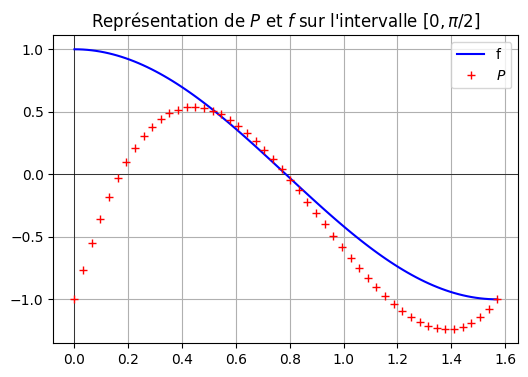

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f_x = np.linspace(0, math.pi/2, 100)
f_y = [f(x) for x in f_x]

P_x = np.linspace(0, math.pi/2, 50)
P_y = [P(x) for x in P_x]

plt.figure(figsize=(6, 4))
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(f_x, f_y, 'b', label = "f")
plt.plot(P_x, P_y, 'r+', label = "$P$")

plt.title("Représentation de $P$ et $f$ sur l'intervalle $[0, \pi/2]$")

plt.legend()

plt.grid(True)
plt.show()

La courbe de $P$ épouse celle de $f$, ce qui est cohérent pour notre approximation !

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6079/3738533315.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Représentation de $P$ et $f$ sur l'intervalle $[-\pi/2, \pi]$")


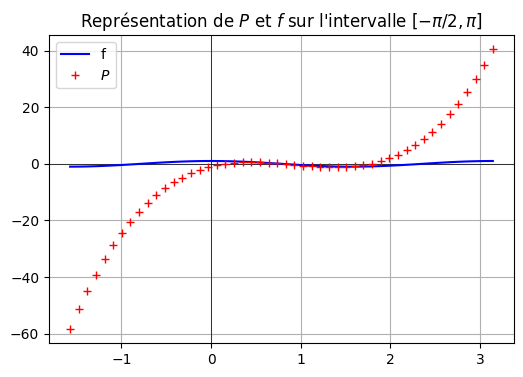

In [ ]:
f_x = np.linspace(-math.pi/2, math.pi, 100)
f_y = [f(x) for x in f_x]

P_x = np.linspace(-math.pi/2, math.pi, 50)
P_y = [P(x) for x in P_x]

plt.figure(figsize=(6, 4))
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(f_x, f_y, 'b', label = "f")
plt.plot(P_x, P_y, 'r+', label = "$P$")

plt.title("Représentation de $P$ et $f$ sur l'intervalle $[-\pi/2, \pi]$")

plt.legend()

plt.grid(True)
plt.show()

$P(x)$ n'étant qu'une approximation locale sur l'intervalle $\left[0, \frac{\pi}{2}\right]$ (délimité par nos points d'interpolation), on observe une notable divergence en dehors de cet intervalle : il s'agit d'une extrapolation !

---

### I.C - L'erreur est humaine

> Représenter graphiquement l’erreur $f(x)−P(x)$ pour $x \in \left[0, \frac{\pi}{2}\right]$. En utilisant un résultat de cours, évaluer un majorant de $|f(x)−P(x)|$ pour tout $x \in \left[0, \frac{\pi}{2}\right]$. Les résultats numériques vous paraissent-ils conformes au résultat théorique attendu ?

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6079/2039256753.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Erreur sur l'intervalle $[0, \pi/2]$")


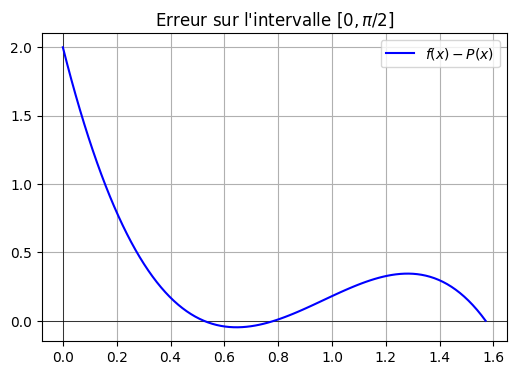

In [ ]:
err_x = np.linspace(0, math.pi/2, 100)
err_y = [f(x)-P(x) for x in err_x]
err_y_abs = [abs(f(x)-P(x)) for x in err_x]

plt.figure(figsize=(6, 4))
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(err_x, err_y, 'b', label = "$f(x) - P(x)$")

plt.title("Erreur sur l'intervalle $[0, \pi/2]$")

plt.legend()

plt.grid(True)
plt.show()

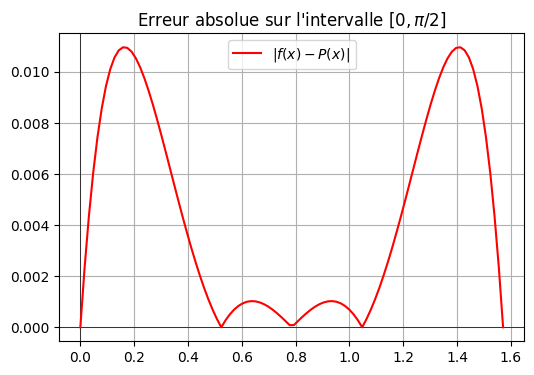

In [ ]:
plt.figure(figsize=(6, 4))
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(err_x, err_y_abs, 'r', label = "$|f(x) - P(x)|$")

plt.title("Erreur absolue sur l'intervalle $[0, \pi/2]$")

plt.legend()

plt.grid(True)
plt.show()

On peut majorer l'erreur comme suit :

$$|f(x) - P_n(X)| = \frac{\max_{\xi \in I(x)} \left| f^{(n+1)}(\xi) \right|}{(n+1)!} \prod_{i=0}^{n} \left| x - x_i \right|$$

Nous travaillons avec $P_3(X)$, donc calculons la dérivée $4-ieme$ de $f$ :

$$f^{(4)}(x) = 16 \cos(2x)$$

Traçons son graphe afin de déterminer sa tendance (tout calcul est bon à éviter en LaTex ! 😎)

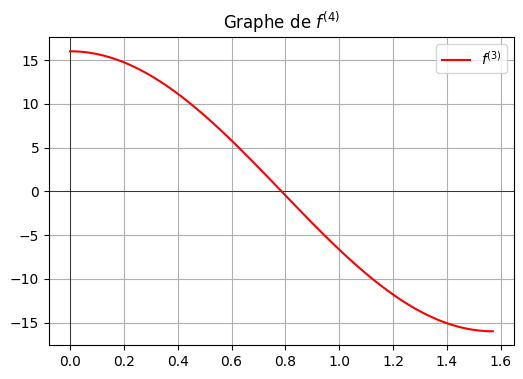

In [ ]:
f4_x = np.linspace(0, math.pi/2, 100)
f4_y = [16*math.cos(2*x) for x in err_x]

plt.figure(figsize=(6, 4))
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(f4_x, f4_y, 'r', label = "$f^{(3)}$")

plt.title("Graphe de $f^{(4)}$")

plt.legend()

plt.grid(True)
plt.show()

Elle est bel et bien décroissante sur $\left[0, \frac{\pi}{2}\right]$ (on le sevait de prime abord bien sûr !). Son maximum est donc à $0$. Ainsi :

$$\max_{\xi \in [0, 1]} \left| f^{(4)}(\xi) \right| = f(0) = 16$$

Finalement, on a la majoration suivante :

$$|(f(x)-P(x)| \leq \frac{2}{3} \left| x \left(x - \frac{\pi}{6}\right) \left(x - \frac{\pi}{4}\right) \left(x - \frac{\pi}{2}\right) \right|$$

On peut vérifier cela !

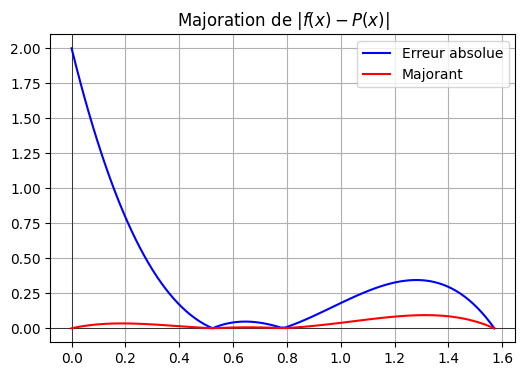

In [ ]:
maj_x = np.linspace(0, math.pi/2, 50)
maj_y = [2/3*abs(x*(x-math.pi/6)*(x-math.pi/4)*(x-math.pi/2)) for x in maj_x]

plt.figure(figsize=(6, 4))
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(err_x, err_y_abs, 'b', label = "Erreur absolue")
plt.plot(maj_x, maj_y, 'r', label = "Majorant")

plt.title("Majoration de $|f(x) - P(x)|$")

plt.legend()

plt.grid(True)
plt.show()

Les résultats numériques sont en effet conformes au résultat théorique, car l'erreur est correctement majorée 🙌

---

## II - Phénomène de Runge

> On définit la fonction `diffdiv(xp, yp)` qui, pour des points d’interpolation donnés par les vecteurs $x_p$ et $y_p = f(x_p)$ (tous deux de dimension $n$), calcule le vecteur $dd$ de dimension $n$ contenant les différences divisées :
>
>$$dd = \left( f[x_0], f[x_0, x_1], \dots, f[x_0, x_1, \dots, x_{n-1}] \right)$$
>
>```python
>def diffdiv(xp, yp):
>    n = len(xp)
>    M = np.array([[0.0] * n] * n)           # Initialisation de la matrice
>    M[0:n, 0] = yp[:]                       # Colonne 0 : les valeurs de yp
>    for i in range(1, n):                   # Parcours des ordres de différences
>        for k in range(n - 1, i - 1, -1):   # Calcul des différences divisées
>            M[k, i] = (M[k, i - 1] - M[k - 1, i - 1]) / (xp[k] - xp[k - i])
>
>    dd = [M[j, j] for j in range(0, n)]     # Extraction des termes diagonaux
>    return dd
>```
>
> On rappelle que ces différences divisées sont définies par :
>
>*   à l’ordre 1, $f[x_k] = f(x_k)$ pour $k = 0, \dots, n-1$
>*   les différences divisées à l’ordre $i + 1$ s’obtiennent, pour $i = 0, \dots, n-1$ à partir des différences divisées à l’ordre $i$ par :
>
>   $$
   f[x_k, \dots, x_{k+i}] = \frac{f[x_{k+1}, \dots, x_{k+i}] - f[x_k, \dots, x_{k+i-1}]}{x_{k+i} - x_k} \quad \text{pour } k = 0, \dots, n - i.
   $$



### II.A - Encore du calcul

> En utilisant l’exemple de l’exercice 1, calculer à la main $dd$.
>
> Programmer la fonction `diffdiv(xp,yp)` et la tester sur cet exemple.

On commence par les plus petit et on remonte. On a alors :
<br><br>
\begin{aligned}
f[x_0] &= f(0) = 1
\\\\
f[x_0, x_1]
&= \frac{f[x_1] - f[x_0]}{x_1 - x_0} \\
&= \frac{f\left(\frac{\pi}{6}\right) - f(0)}{\frac{\pi}{6} - 0} \\
&= 6 \frac{\frac 1 2 - 1}{\pi} \\
&= -\frac{3}{\pi}
\\\\
f[x_0, x_1, x_2]
&= \frac{f[x_1, x_2] - f[x_0, x_1]}{x_2 - x_0} \\
&= \frac{\frac{f[x_2] - f[x_1]}{x_2 - x_1} - \frac{f[x_1] - f[x_0]}{x_1 - x_0}}{x_2 - x_0} \\
&= \frac{\frac{f(\frac{\pi}{4}) - f\left(\frac{\pi}{6}\right)}{\frac{\pi}{4} - \frac{\pi}{6}} - \frac{f\left(\frac{\pi}{6}\right) - f(0)}{\frac{\pi}{6} - 0}}{\frac{\pi}{4} - 0} \\
&= \frac{\frac{-\frac{1}{2}}{\frac{\pi}{12}} + \frac{\frac{1}{2}}{\frac{\pi}{6}}}{\frac{\pi}{4}}  \\
&=  4 \frac{\frac{-12}{2\pi}+\frac{6}{2\pi}}{\pi} \\
&=  -\frac{12}{\pi^2}
\\\\
f[x_0, x_1, x_2, x_3]
&= \frac{f[x_1, x_2, x_3] - f[x_0, x_1, x_2]}{x_3 - x_0} \\
&= \frac{\frac{f[x_2, x_3] - f[x_1, x_2]}{x_3 - x_1} - f[x_0, x_1, x_2]}{x_3 - x_0} \\
&= \frac{\frac{\frac{f[x_3] - f[x_2]}{x_3 - x_2} - \frac{f[x_2] - f[x_1]}{x_2 - x_1}}{x_3 - x_1} - f[x_0, x_1, x_2]}{x_3 - x_0} \\
&= \frac{\frac{\frac{-1 - 0}{\frac{\pi}{4}} - \frac{0 - \frac{1}{2}}{\frac{\pi}{4} - \frac{\pi}{6}}}{\frac{\pi}{2} - \frac{\pi}{6}} - \left(-\frac{12}{\pi^2}\right)}{\frac{\pi}{2} - 0} \\
&= \frac{\frac{-\frac{4}{\pi} + \frac{6}{\pi}}{\frac{\pi}{3}} + \frac{12}{\pi^2}}{\frac{\pi}{2}} \\
&= \frac{18}{\pi^2} \cdot \frac{2}{\pi} = \frac{36}{\pi^3}
\end{aligned}

En somme, nous avons obtenu :
- $f[x_0] = 1$
- $f[x_0, x_1] = -\frac{3}{\pi}$
- $f[x_0, x_1, x_2] = -\frac{12}{\pi^2}$
- $f[x_0, x_1, x_2, x_3] = \frac{36}{\pi^3}$

En substituant les valeurs :
$$ dd = (1, -\frac{3}{\pi}, -\frac{12}{\pi^2}, \frac{36}{\pi^3}) $$

avec $f[x_0] = f(0) = 0, f[x_1] = f(\frac{\pi}{6}) = \frac 1 2, f[x_2] = f(\frac{\pi}{4}) = 0, f[x_3] = f(\frac{\pi}{2}) = -1$

On peut désormais la tester !

In [ ]:
def diffdiv(xp, yp):
   n = len(xp)
   M = np.array([[0.0] * n] * n)
   M[0:n, 0] = yp[:]
   for i in range(1, n):
       for k in range(n - 1, i - 1, -1):
           M[k, i] = (M[k, i - 1] - M[k - 1, i - 1]) / (xp[k] - xp[k - i])

   dd = [M[j, j] for j in range(0, n)]
   return dd

print(diffdiv([0, math.pi/6, math.pi/4, math.pi/2], [1, 1/2, 0, -1]))

[np.float64(1.0), np.float64(-0.9549296585513721), np.float64(-1.2158542037080529), np.float64(1.1610552395951812)]


C'est honnête !

---

### II.B - Bonjour Horner

> Écrire une fonction `myhorner(dd,xp,x)` qui, étant donnés les différences divisées $dd$, les points d’interpolation $x_p$ et le vecteur $x$, calcule par l’algorithme de Horner la valeur du polynôme d’interpolation $P$ en chacune des coordonnées de $x$.

On peut écrire la fonction suivante :

In [ ]:
def myhorner(dd, xp, x):
    n = len(dd)
    result = np.zeros_like(x)   # Initialisation du résultat
    for i in range(len(x)):     # Pour chaque point où évaluer P(x)
        value = dd[-1]
        for k in range(n - 2, -1, -1):
            value = value * (x[i] - xp[k]) + dd[k]
        result[i] = value
    return result

In [ ]:
# TEST ---
xp = [0, math.pi/6, math.pi/4, math.pi/2]
yp = [1, 1/2, 0, -1]
dd = diffdiv(xp, yp)

myhorner(dd, xp, xp)

array([ 1. ,  0.5,  0. , -1. ])

---

### II.C - Et si on comparait ?

> Écrire une fonction `comparaison(f,a,b,n)` qui, étant donnés la fonction `f`, l’intervalle d’interpolation $[a, b]$ et le nombre de points d’interpolation $n$ :
> * définit les points d’interpolation $(x_i^1)_{0\leqslant i \leqslant n-1}$ et $(x_i^2)_{0\leqslant i \leqslant n-1}$ :
>   * points équirépartis : $x_i^1 = a + i \frac{b-a}{n-1}$ pour $0 \leqslant i \leqslant n-1$,
>   * et points de Tchebychev : $x_i^2 = \frac{a+b}{2} + \frac{b-a}{2} \cos\left((2i+1)\frac{\pi}{2n}\right)$ pour $0 \leqslant i \leqslant n-1$ ;
> * calcule les polynômes d’interpolation $P_1$ et $P_2$ de $f$ respectivement aux points $(x_i^1)_{0\leqslant i \leqslant n-1}$ et $(x_i^2)_{0\leqslant i \leqslant n-1}$ ;
> * représente sur un même graphique la fonction, les points d’interpolation et les polynômes d’interpolation.

A nos claviers !

In [ ]:
def comparaison(f, a, b, n):
    # Points équirépartis
    x1 = np.linspace(a, b, n)
    y1 = f(x1)
    dd1 = diffdiv(x1, y1)

    # Points de Tchebychev
    x2 = 0.5 * (a + b) + 0.5 * (b - a) * np.cos((2 * np.arange(n) + 1) * np.pi / (2 * n))
    y2 = f(x2)
    dd2 = diffdiv(x2, y2)

    # Évaluation sur un ensemble dense de points
    x_dense = np.linspace(a, b, 500)
    p1 = myhorner(dd1, x1, x_dense)
    p2 = myhorner(dd2, x2, x_dense)

    # Tracé des résultats
    plt.figure(figsize=(10, 6))
    plt.plot(x_dense, f(x_dense), label="f(x)", color="black", linewidth=2)
    plt.plot(x_dense, p1, label="P1 (équirépartis)", linestyle="--", color="blue")
    plt.plot(x_dense, p2, label="P2 (Tchebychev)", linestyle="--", color="red")
    plt.scatter(x1, y1, label="Points équirépartis", color="blue")
    plt.scatter(x2, y2, label="Points de Tchebychev", color="red")
    plt.legend()
    plt.grid()
    plt.title("Interpolation de f(x)")
    plt.show()

---

### II.D - Un beau tracé

> Tester le programme pour la fonction $f(x) = \frac{1}{1+x^2}$ sur $[-1, 1]$, en utilisant les deux types de subdivisions (régulière et Tchebychev).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

def comparaison(f, a, b, n):
    # grille fine pour affichage
    x_plot = np.linspace(a, b, 500)
    y_true = f(x_plot)

    # noeuds équidistants
    x1 = np.linspace(a, b, n)
    y1 = f(x1)
    P1 = BarycentricInterpolator(x1, y1)

    # noeuds de Tchebychev
    k = np.arange(n)
    x2 = 0.5*(a+b) + 0.5*(b-a)*np.cos((2*k+1)*np.pi/(2*n))
    x2 = np.sort(x2)
    y2 = f(x2)
    P2 = BarycentricInterpolator(x2, y2)

    # tracé
    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, y_true, 'k-', label='f(x)')
    plt.plot(x_plot, P1(x_plot), 'b--', label='P1 (équirépartis)')
    plt.plot(x_plot, P2(x_plot), 'r--', label='P2 (Tchebychev)')
    plt.scatter(x1, y1, color='blue', label='Points équirépartis')
    plt.scatter(x2, y2, color='red', label='Points de Tchebychev')

    plt.title("Interpolation de f(x)")
    plt.legend()
    plt.grid()
    plt.show()

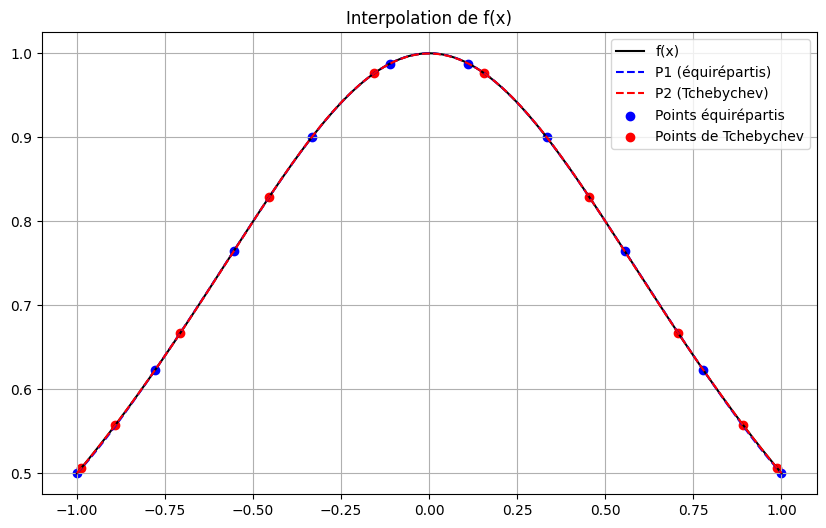

In [ ]:
f = lambda x: 1 / (1 + x**2)
comparaison(f, -1, 1, 10)

---

### II.E - Un tracé d'autant plus beau

> Tester le programme toujours pour la fonction $f(x) = \frac{1}{1+x^2}$, mais cette fois sur $[-5, 5]$, en utilisant les deux types de subdivisions (régulière et Tchebychev).

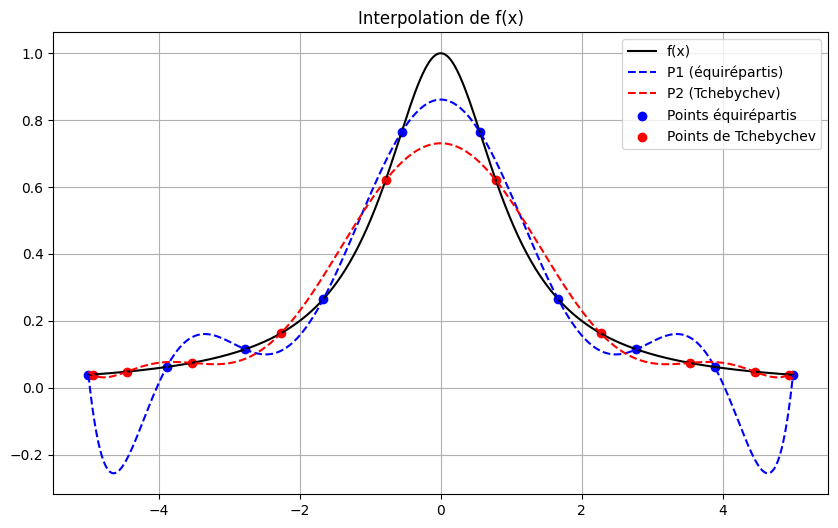

In [ ]:
# Interpolation sur [-5, 5]
comparaison(f, -5, 5, 10)

---

### II.F - Un résultat spectaculaire !

> Comparer et commenter les comportements observés dans les questions **D** et **E** lorsque $n$ augmente.

Le constat est sans appel : non seulement l'augmentation de $n$ (du nombre de points d'interpolation) n'améliore pas l'approximation, mais elle l'empire considérablement.

C'est ce phénomène étrange que l'on appelle **phénomène de Runge**.

[Cette vidéo](https://www.youtube.com/watch?v=ba_ixwaZYYc.) par ailleurs apporte une très belle ouverture à ce phénomène, mais illustre également le cours d'une manière élégante.

A défaut de s'obstiner à interpoler une pléthore de points, il serait idoine de chercher un moyen de tracer des courbes qui ont simplement l'allure de la notre ! C'est une idée qui donnera lieu au théorème d'approximation de Weierstrass, mais également à nos délicieuses courbes de Bézier que nous avons eu le luxe d'aborder en Infographie.

---

### II.G - Un nouvel algorithme

> On donne un nouvel algorithme pour le calcul des différences divisées :
>
>```python
def diffdiv (xp ,yp):
  n = len(xp)
  dd[:]=yp[:]
  for i in range (1,n):
    for k in range (n-1,i-1,-1):
      dd[k]=(dd[k]-dd[k-1])/(xp[k]-xp[k-i])
  return dd
```
> Expliquer pourquoi les deux algorithmes donnent le même résultat et comparer leur complexité en terme de ressource mémoire utilisée.

Pour commencer, nos 2 programmes nous donnent le vecteur $dd$, et donc toutes les différences divisées. Mais la technique utilisée n'est pas la même :

In [ ]:
def diffdiv (xp, yp):
    n = len(xp)
    dd = [0] * n      # Erreur hein !
    dd[:] = yp[:]
    for i in range (1, n):
        for k in range(n-1,i-1, -1):
            dd[k] = (dd[k] - dd[k-1]) / (xp[k] - xp[k-i])
    return dd

---
<center>

#### ⠀

# Fin.

</center>